# Send more money!
**Course:** Data Structures & Algorithms 1

## Implementation

In [5]:
def getUniqueLetters(words):
    combinedWords = []
    for i in range(len(words)):
        combinedWords += words[i]

    return list(dict.fromkeys(combinedWords))

def getFirstLetters(words):
    firstLetters = []

    for i in range(len(words)):
        firstLetters.append(words[i][0])

    return firstLetters

def assignCoversionToWord(word, mappings):
    num = 0
    for i in range(len(word)):
        num = num * 10 + mappings[word[i]]

    return num

def checkSuffice(words, mappings):
    count = 0

    for i in range(0, len(words)-1):
        count += assignCoversionToWord(words[i], mappings)

    return count == assignCoversionToWord(words[len(words)-1], mappings)

def printSolution(words, mappings):
    for i in range(len(words)-1):
        print(str(assignCoversionToWord(words[i], mappings)) + " +")
    print(" = " + str(assignCoversionToWord(words[len(words)-1], mappings)))
    

def solveCryptarithmetic(letterIndex, words, mappings, firstLetters, uniqueLetters):

    if len(words) == 0:
        return False

    if letterIndex == len(uniqueLetters):
        return checkSuffice(words, mappings)

    
    for i in range(10):
        if (firstLetters.count(uniqueLetters[letterIndex]) != 0 and i == 0) or i in mappings.values():
            continue
        
        mappings[uniqueLetters[letterIndex]] = i

        result = solveCryptarithmetic(letterIndex + 1, words, mappings, firstLetters, uniqueLetters)

        if result == True:
            return True
        
        mappings.pop(uniqueLetters[letterIndex])

    return False    

words = ["SEND", "MORE", "MONEY"]

firstLetters = getFirstLetters(words)
uniqueLetters = getUniqueLetters(words)
mappings = {}

if solveCryptarithmetic(0, words, mappings, firstLetters, uniqueLetters):
    printSolution(words, mappings)
else:
    print("No solution")

9567 +
1085 +
 = 10652


## Performance test

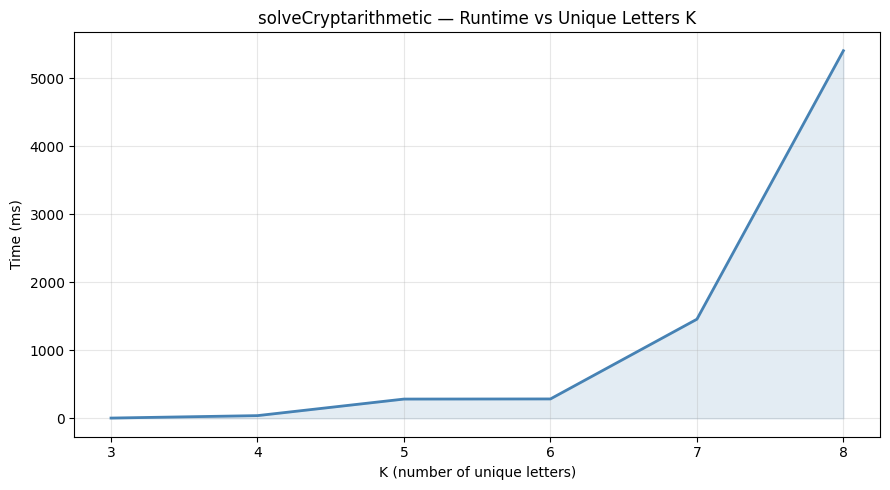

In [7]:
import time
import matplotlib.pyplot as plt

puzzles = [
    (3, ["GO",    "TO",    "OUT"   ]),
    (4, ["AB",    "CD",    "ACE"   ]),
    (5, ["ABC",   "DE",    "AFBC"  ]),
    (6, ["ABCD",  "EF",    "AEFCD" ]),
    (7, ["ABCDE", "FG",    "AFGCDE"]),
    (8, ["SEND",  "MORE",  "MONEY" ]),
]

k_values = []
times = []

for k, puzzle in puzzles:
    fl = getFirstLetters(puzzle)
    ul = getUniqueLetters(puzzle)
    start = time.perf_counter()
    solveCryptarithmetic(0, puzzle, {}, fl, ul)
    end = time.perf_counter()
    k_values.append(k)
    times.append((end - start) * 1000)


plt.figure(figsize=(9, 5))
plt.plot(k_values, times, color='steelblue', linewidth=2)
plt.fill_between(k_values, times, alpha=0.15, color='steelblue')
plt.xlabel('K (number of unique letters)')
plt.ylabel('Time (ms)')
plt.title('solveCryptarithmetic — Runtime vs Unique Letters K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_plot.png', dpi=150)
plt.show()

## Complexity Analysis

Since in the worst case we can have  10 unique characters, and for every next character the options become -1: for the first letter 10, then 9, 8, etc. and the algorithm would have to try all possible combinations, before finding the right one if t exists, thus why it's complexity is O(n!).

## Unit tests

In [8]:
import unittest

class TestsolveCryptarithmetic(unittest.TestCase):
    def test_solvable_Cryptarithmetic(self):
        self.assertEqual(solveCryptarithmetic(0, ["SEND","MORE","MONEY"], {}, ["S","M"], ["S","E","N","D","O","R","Y"]), True)

    def test_unsolvable_Cryptarithmetic(self):
        self.assertEqual(solveCryptarithmetic(0, ["I","AM","HERE"], {}, ["I","A","H"], ["I","A","M","H","E","R"]), False)

    def test_word_not_in_file(self):
        self.assertEqual(solveCryptarithmetic(0, [], {}, [], []), False)

unittest.main(argv=[""], exit=False, verbosity=2)


test_solvable_Cryptarithmetic (__main__.TestsolveCryptarithmetic.test_solvable_Cryptarithmetic) ... ERROR
test_unsolvable_Cryptarithmetic (__main__.TestsolveCryptarithmetic.test_unsolvable_Cryptarithmetic) ... ok
test_word_not_in_file (__main__.TestsolveCryptarithmetic.test_word_not_in_file) ... ok

ERROR: test_solvable_Cryptarithmetic (__main__.TestsolveCryptarithmetic.test_solvable_Cryptarithmetic)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "C:\Users\MSI Prestige\AppData\Local\Temp\ipykernel_3448\3771499399.py", line 5, in test_solvable_Cryptarithmetic
    self.assertEqual(solveCryptarithmetic(0, ["SEND","MORE","MONEY"], {}, ["S","M"], ["S","E","N","D","O","R","Y"]), True)
                     ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MSI Prestige\AppData\Local\Temp\ipykernel_3448\2019350666.py", line 52, in solveCryptarithmetic
    result = solv